<a href="https://colab.research.google.com/github/atoholj/capstone-final-injury-risk-prediction/blob/main/01_eda_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 01 — Exploratory Data Analysis (EDA)
## Injury Risk Prediction from Athlete Monitoring Signals (Capstone)

### Goal
The goal of this project is to predict short-term musculoskeletal injury risk using athlete training load, movement/biomechanics, and recovery signals. A strong model could support an early warning system that helps coaches and athletes adjust training plans to reduce time-loss injuries.

### Data Problem
This is a binary classification problem:
- Predict whether an athlete is at risk of injury (`injury_risk = 1`) vs not at risk (`injury_risk = 0`)
- Injury cases are rare (class imbalance), so we will prioritize metrics like **recall** and **PR-AUC** over accuracy.

### Expected Results
The expected outcome is a model that can flag most injury-risk cases early (high recall), while keeping false alarms manageable.

### Dataset
- Source: Kaggle multimodal sports injury prediction dataset  
- Link: https://www.kaggle.com/datasets/anjalibhegam/multimodal-sports-injury-prediction-dataset?resource=download
- Size: ~5,430 rows × 31 columns  
- Target label: `injury_risk` (0 = no risk, 1 = risk)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)




In [6]:
DATA_PATH = "/content/sports_multimodal_data.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,heart_rate,emg_amplitude,skin_temp,gsr,respiratory_rate,spo2,bp_systolic,bp_diastolic,fatigue_index,acceleration,angular_velocity,body_orientation,ground_reaction_force,step_count,cadence,jump_height,range_of_motion,impact_force,gait_symmetry,speed,altitude,ambient_temp,humidity,heat_index,training_duration,previous_injury_history,rest_period,repetition_count,workload_intensity,acc_rms,injury_risk
0,74.967142,0.306745,33.154617,0.065939,17.977078,97.246223,117.657793,80.109155,54.831785,-0.718127,-0.003807,-84.236232,585.699897,108,78.700411,0.283371,95.614986,233.841097,0.904631,4.656892,607.278310,21.009398,24.789760,25.855921,62.680175,0,5.117926,31,4.754003,0.904436,0
1,68.617357,0.279614,33.035970,0.385663,11.316872,99.553279,124.918440,80.260665,59.224133,1.942509,-0.461214,-42.132891,605.157129,121,71.238662,0.546651,116.055070,228.592770,0.861567,9.737281,792.188596,18.718507,34.465135,28.447909,68.193399,0,6.045622,27,4.704938,1.184699,0
2,76.476885,0.134006,31.874060,0.339236,19.038077,98.053515,114.198061,88.185059,47.614986,0.567535,0.508938,19.075221,550.060661,90,78.796626,0.437352,48.951697,233.282468,0.917264,1.544627,681.269471,16.446042,77.616889,36.372307,89.855417,1,7.266212,36,5.687716,0.900029,0
3,85.230299,0.679033,32.550676,0.162285,14.772505,98.930086,124.997166,78.376715,36.039562,-2.097921,0.265441,126.166024,592.640495,90,88.431162,0.456024,39.267751,248.691408,0.898814,7.211323,762.828281,15.027612,34.447985,9.636166,69.332707,0,9.578920,27,6.770770,1.146620,0
4,67.658466,0.336259,33.003275,0.278293,14.371073,98.232013,117.869898,87.285347,55.066480,1.207819,0.263829,43.465694,564.912054,95,90.963894,0.409951,83.095650,607.557596,0.845434,9.955233,417.159660,25.860483,71.415446,28.544690,119.589317,0,6.276707,28,-0.172192,0.900294,0


In [7]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)


Shape: (5430, 31)

Columns:
Index(['heart_rate', 'emg_amplitude', 'skin_temp', 'gsr', 'respiratory_rate',
       'spo2', 'bp_systolic', 'bp_diastolic', 'fatigue_index', 'acceleration',
       'angular_velocity', 'body_orientation', 'ground_reaction_force',
       'step_count', 'cadence', 'jump_height', 'range_of_motion',
       'impact_force', 'gait_symmetry', 'speed', 'altitude', 'ambient_temp',
       'humidity', 'heat_index', 'training_duration',
       'previous_injury_history', 'rest_period', 'repetition_count',
       'workload_intensity', 'acc_rms', 'injury_risk'],
      dtype='object')


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5430 entries, 0 to 5429
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   heart_rate               5430 non-null   float64
 1   emg_amplitude            5430 non-null   float64
 2   skin_temp                5430 non-null   float64
 3   gsr                      5430 non-null   float64
 4   respiratory_rate         5430 non-null   float64
 5   spo2                     5430 non-null   float64
 6   bp_systolic              5430 non-null   float64
 7   bp_diastolic             5430 non-null   float64
 8   fatigue_index            5430 non-null   float64
 9   acceleration             5430 non-null   float64
 10  angular_velocity         5430 non-null   float64
 11  body_orientation         5430 non-null   float64
 12  ground_reaction_force    5430 non-null   float64
 13  step_count               5430 non-null   int64  
 14  cadence                 

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


,0


In [10]:
print("Duplicates:", df.duplicated().sum())


Duplicates: 0


In [11]:
target_col = "injury_risk"

df[target_col].value_counts()


,count
injury_risk,
0,5160
1,270


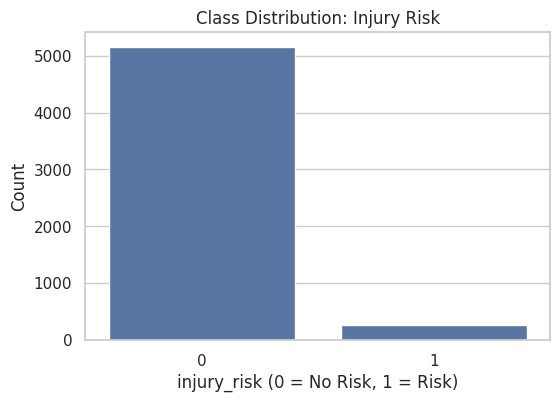

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Class Distribution: Injury Risk")
plt.xlabel("injury_risk (0 = No Risk, 1 = Risk)")
plt.ylabel("Count")
plt.show()


In [13]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
heart_rate,5430.0,70.020682,9.947648,37.587327,63.380668,70.071208,76.614017,109.262377
emg_amplitude,5430.0,0.546094,0.257870,0.100048,0.326396,0.542621,0.767588,0.999706
skin_temp,5430.0,33.008845,1.492605,27.116400,32.005512,33.011805,34.003980,38.143366
gsr,5430.0,0.279551,0.129870,0.050022,0.167967,0.281142,0.391472,0.499955
respiratory_rate,5430.0,15.951653,2.955197,4.430874,13.901322,15.991920,17.959894,26.834050
spo2,5430.0,97.994149,0.999271,94.467182,97.308670,97.999610,98.680309,101.691625
bp_systolic,5430.0,119.775922,12.271519,66.412754,111.338549,119.676402,128.166929,164.734000
bp_diastolic,5430.0,80.081034,7.864167,52.415657,74.667551,80.167170,85.375101,106.367236
fatigue_index,5430.0,50.156254,9.913094,7.046090,43.537513,50.179794,56.922337,85.365317
acceleration,5430.0,-0.009271,1.006589,-3.317318,-0.686116,-0.018379,0.666043,3.401876


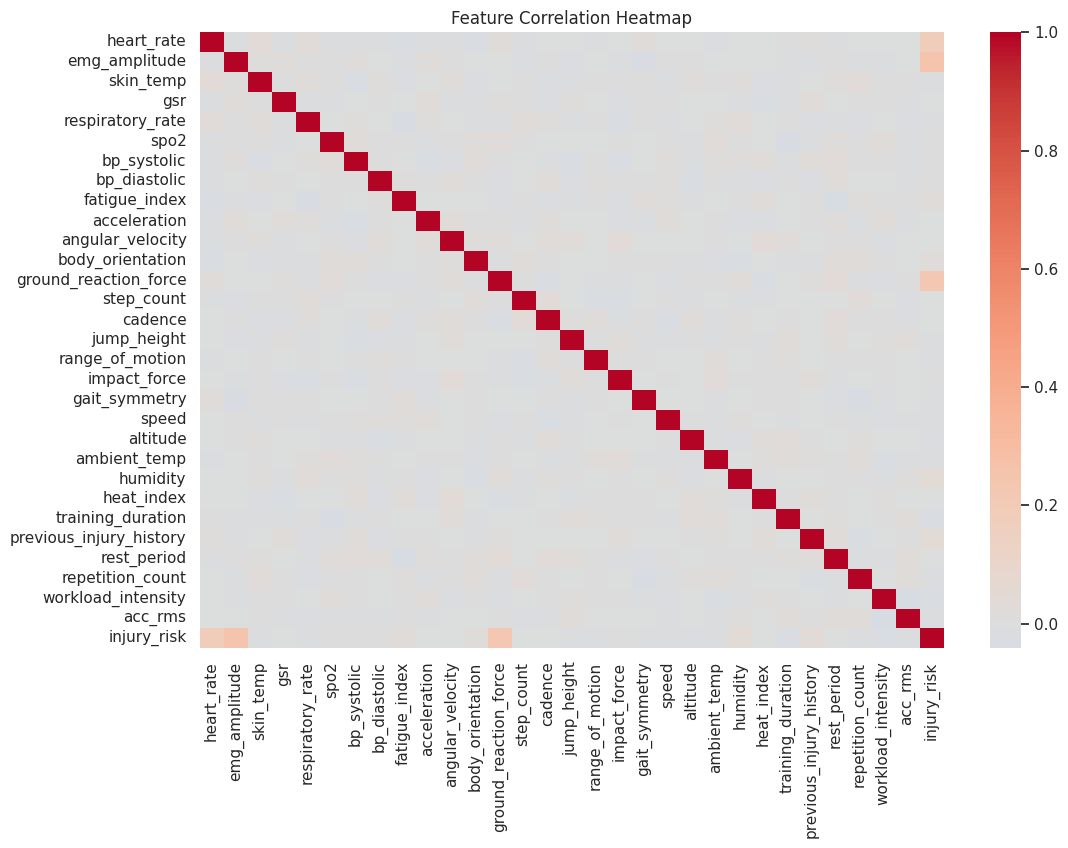

In [14]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


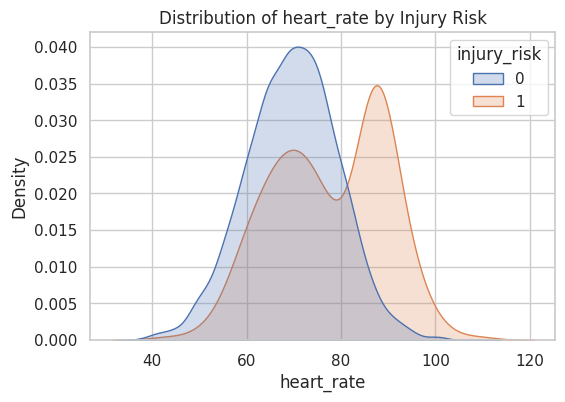

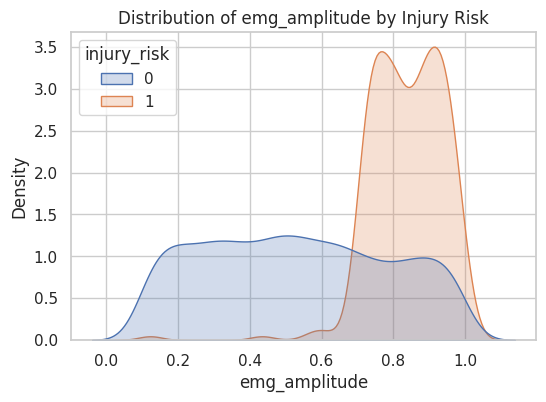

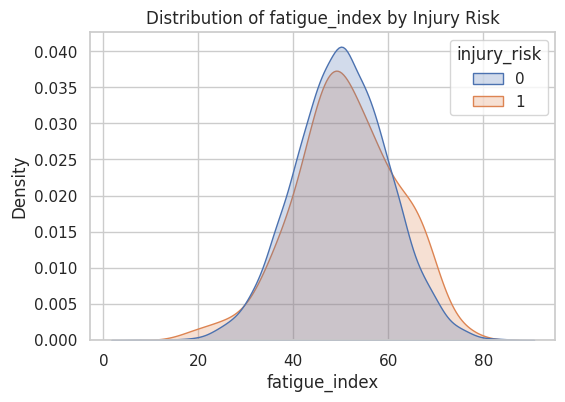

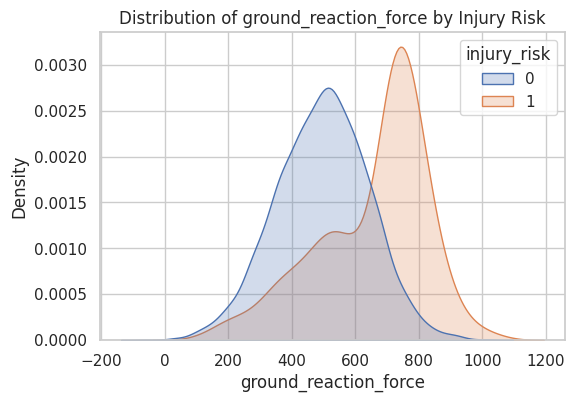

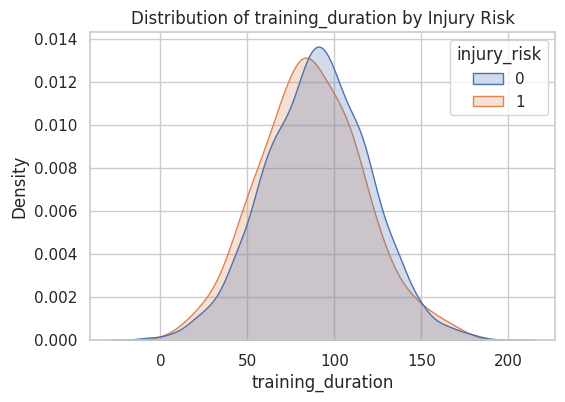

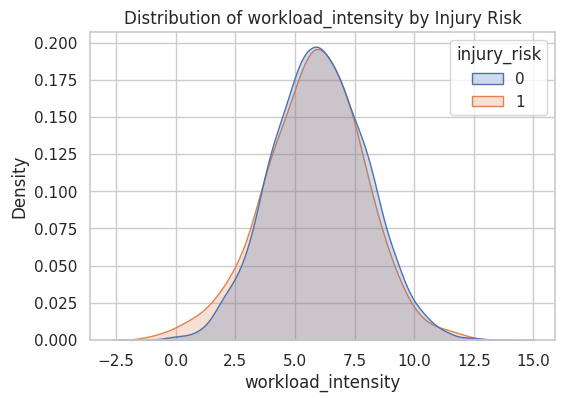

In [15]:
key_features = [
    "heart_rate",
    "emg_amplitude",
    "fatigue_index",
    "ground_reaction_force",
    "training_duration",
    "workload_intensity",
]

for col in key_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue=target_col, fill=True, common_norm=False)
    plt.title(f"Distribution of {col} by Injury Risk")
    plt.show()


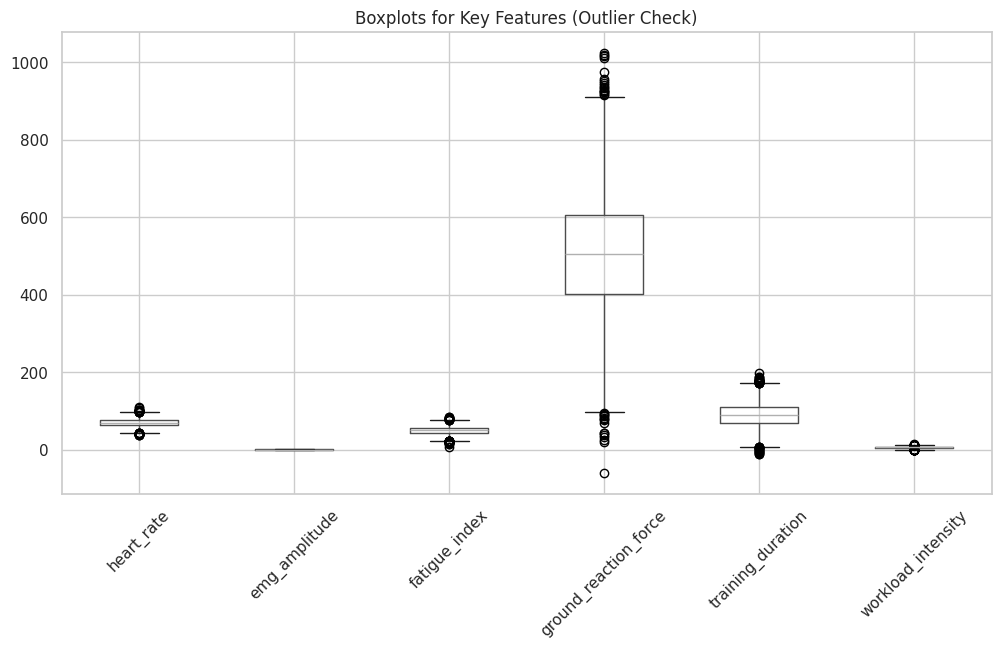

In [16]:
plt.figure(figsize=(12,6))
df[key_features].boxplot(rot=45)
plt.title("Boxplots for Key Features (Outlier Check)")
plt.show()


In [17]:
X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (5430, 30)
y shape: (5430,)


In [18]:
X.dtypes.value_counts()


,count
float64,27
int64,3


In [19]:
clean_path = "/content/sports_multimodal_data_clean.csv"
df.to_csv(clean_path, index=False)

print("Saved cleaned dataset to:", clean_path)


Saved cleaned dataset to: /content/sports_multimodal_data_clean.csv


## Key EDA Takeaways

1. The dataset contains athlete physiological, biomechanical, and workload signals that may relate to injury risk.
2. The target variable (`injury_risk`) is imbalanced, meaning injury cases occur much less frequently than non-injury cases.
3. Several features show different distribution patterns between injury-risk and non-risk groups, suggesting predictive potential.
4. The model evaluation will prioritize **recall** and **PR-AUC** to better reflect performance on the rare injury-risk class.
